In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_df = pd.read_csv(
    "../data/cleaned/olist_master_cleaned.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_creation_date,review_answer_timestamp,delivery_days,delivery_delay,total_order_value,shipping_ratio,order_month,order_year,order_quarter,purchase_weekday
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11 00:00:00,2017-10-12 03:43:48,8.0,-8.0,38.71,0.290764,October,2017,Q4,Monday
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11 00:00:00,2017-10-12 03:43:48,8.0,-8.0,38.71,0.290764,October,2017,Q4,Monday
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11 00:00:00,2017-10-12 03:43:48,8.0,-8.0,38.71,0.290764,October,2017,Q4,Monday
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08 00:00:00,2018-08-08 18:37:50,13.0,-6.0,141.46,0.191744,July,2018,Q3,Tuesday
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-18 00:00:00,2018-08-22 19:07:58,9.0,-18.0,179.12,0.120200,August,2018,Q3,Wednesday


In [2]:
master_df.shape

(119143, 44)

In [3]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  str           
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  str           
 11  customer_st

In [4]:
master_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,...,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,delivery_days,delivery_delay,total_order_value,shipping_ratio,order_year
count,119143,118966,117057,115722,119143,119143.000000,118310.000000,118310.000000,118310.000000,119143.000000,...,119143.000000,119140.000000,119140.000000,119140.000000,118146.000000,115722.000000,115722.000000,118310.000000,118310.000000,119143.000000
mean,2017-12-29 18:36:13.115760,2017-12-30 04:49:18.425726,2018-01-03 08:24:34.395525,2018-01-12 20:55:38.199616,2018-01-22 15:21:10.241642,35033.451298,1.196543,120.646603,20.032387,48.836465,...,23.052785,1.094737,2.941246,172.735135,4.015582,12.022589,-12.048392,140.678990,0.322203,2017.535290
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,0.850000,0.000000,5.000000,...,6.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-147.000000,6.080000,0.000000,2016.000000
25%,2017-09-10 20:15:46,2017-09-11 15:50:48.500000,2017-09-14 19:52:12,2017-09-22 21:54:31.250000,2017-10-02 00:00:00,11250.000000,1.000000,39.900000,13.080000,43.000000,...,15.000000,1.000000,1.000000,60.850000,4.000000,6.000000,-17.000000,55.240000,0.134787,2017.000000
50%,2018-01-17 11:59:12,2018-01-17 16:49:49,2018-01-23 17:03:08,2018-02-01 03:17:55,2018-02-14 00:00:00,24240.000000,1.000000,74.900000,16.280000,52.000000,...,20.000000,1.000000,2.000000,108.160000,5.000000,10.000000,-13.000000,91.990000,0.232171,2018.000000
75%,2018-05-03 13:18:30,2018-05-03 16:56:53,2018-05-07 14:57:00,2018-05-15 00:08:31.500000,2018-05-25 00:00:00,58475.000000,1.000000,134.900000,21.180000,57.000000,...,30.000000,1.000000,4.000000,189.240000,5.000000,15.000000,-7.000000,157.615000,0.394058,2018.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,6735.000000,409.680000,76.000000,...,118.000000,29.000000,24.000000,13664.080000,5.000000,209.000000,188.000000,6929.310000,26.235294,2018.000000
std,NaN,NaN,NaN,NaN,NaN,29823.198969,0.699489,184.109691,15.836850,9.936910,...,11.709874,0.730141,2.777848,267.776077,1.400436,9.454922,10.163801,191.239906,0.351861,0.505591




# EDA 1: Monthly Revenue Trend

## Business Question

How does revenue change over time?

## Business Importance

Understanding revenue trends helps stakeholders identify business growth, seasonality, and periods requiring strategic intervention.

In [5]:
monthly_revenue = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))[
        "total_order_value"
    ]
    .sum()
    .reset_index()
)

monthly_revenue["order_purchase_timestamp"] = (
    monthly_revenue["order_purchase_timestamp"]
    .astype(str)
)

monthly_revenue

,order_purchase_timestamp,total_order_value
0,2016-09,354.75
1,2016-10,58730.85
2,2016-12,19.62
3,2017-01,148030.11
4,2017-02,303648.31
5,2017-03,459778.64
6,2017-04,449707.81
7,2017-05,634762.22
8,2017-06,531052.06
9,2017-07,631341.57


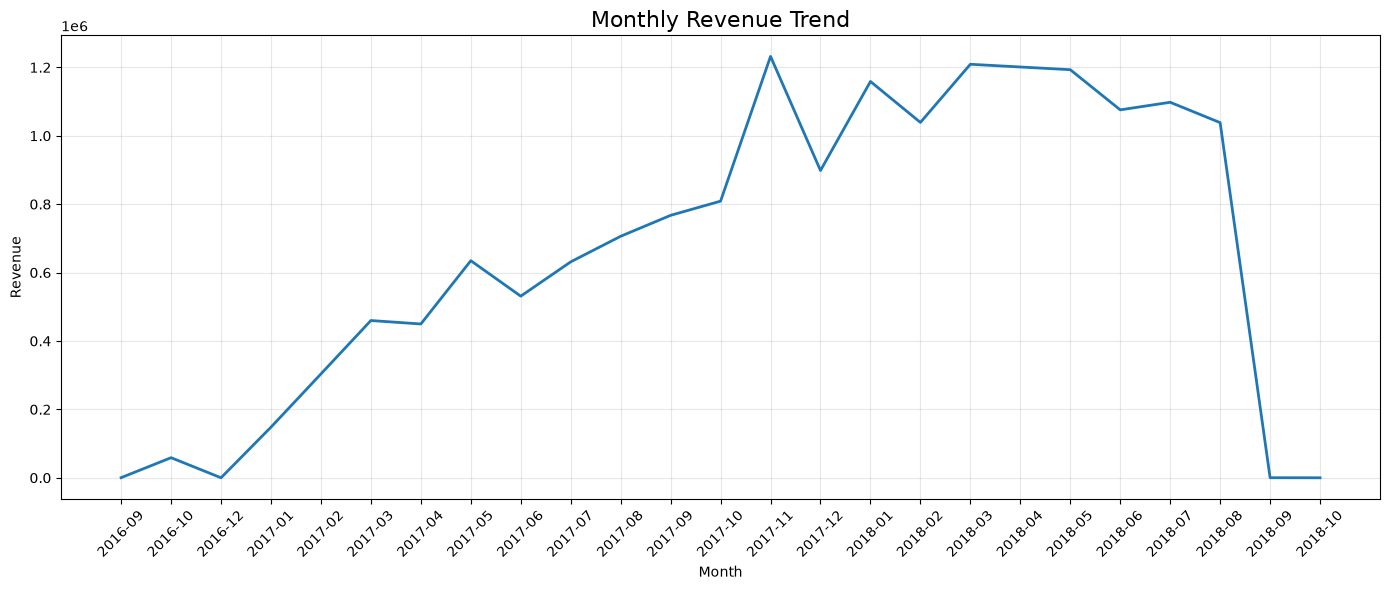

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["order_purchase_timestamp"],
    monthly_revenue["total_order_value"],
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [7]:
monthly_orders = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))[
        "order_id"
    ]
    .nunique()
    .reset_index()
)

monthly_orders["order_purchase_timestamp"] = (
    monthly_orders["order_purchase_timestamp"]
    .astype(str)
)

monthly_orders

,order_purchase_timestamp,order_id
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


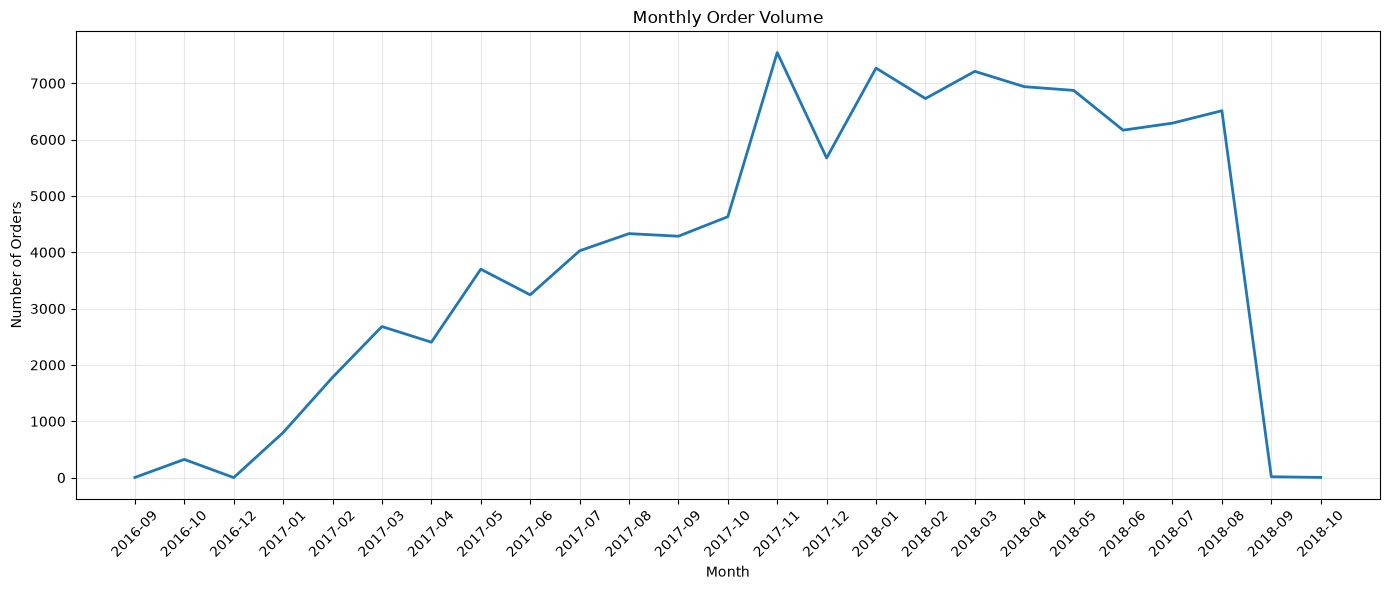

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders["order_purchase_timestamp"],
    monthly_orders["order_id"],
    linewidth=2
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [9]:
monthly_customers = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))[
        "customer_id"
    ]
    .nunique()
    .reset_index()
)

monthly_customers["order_purchase_timestamp"] = (
    monthly_customers["order_purchase_timestamp"]
    .astype(str)
)

monthly_customers

,order_purchase_timestamp,customer_id
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [10]:
comparison = monthly_orders.merge(
    monthly_customers,
    on="order_purchase_timestamp"
)

comparison.columns = [
    "Month",
    "Orders",
    "Customers"
]

comparison["Difference"] = (
    comparison["Orders"] -
    comparison["Customers"]
)

comparison

,Month,Orders,Customers,Difference
0,2016-09,4,4,0
1,2016-10,324,324,0
2,2016-12,1,1,0
3,2017-01,800,800,0
4,2017-02,1780,1780,0
5,2017-03,2682,2682,0
6,2017-04,2404,2404,0
7,2017-05,3700,3700,0
8,2017-06,3245,3245,0
9,2017-07,4026,4026,0


In [11]:
comparison["Difference"].describe()

count    25.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: Difference, dtype: float64

# EDA 2: Average Order Value (AOV)

## Business Question

Are customers spending more per order over time?

## Business Importance

Average Order Value (AOV) is one of the most important ecommerce KPIs. It helps businesses understand whether revenue growth is driven by customers purchasing more expensive products or simply by increasing order volume.

Formula:

AOV = Total Revenue / Number of Orders

In [12]:
aov = monthly_revenue.merge(
    monthly_orders,
    on="order_purchase_timestamp"
)

aov["AOV"] = (
    aov["total_order_value"] /
    aov["order_id"]
)

aov.rename(columns={
    "order_purchase_timestamp": "Month",
    "total_order_value": "Revenue",
    "order_id": "Orders"
}, inplace=True)

aov

,Month,Revenue,Orders,AOV
0,2016-09,354.75,4,88.687500
1,2016-10,58730.85,324,181.268056
2,2016-12,19.62,1,19.620000
3,2017-01,148030.11,800,185.037637
4,2017-02,303648.31,1780,170.588938
5,2017-03,459778.64,2682,171.431260
6,2017-04,449707.81,2404,187.066477
7,2017-05,634762.22,3700,171.557357
8,2017-06,531052.06,3245,163.652407
9,2017-07,631341.57,4026,156.816088


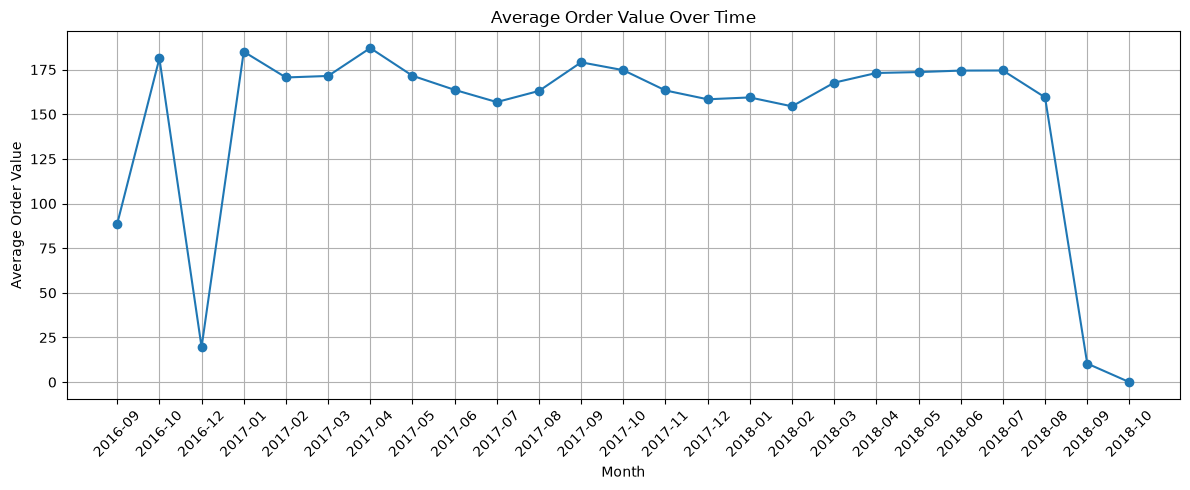

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    aov["Month"],
    aov["AOV"],
    marker="o"
)

plt.title("Average Order Value Over Time")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# EDA 3: Top Product Categories by Revenue

## Business Question
Which product categories contribute the most to overall revenue?

## Business Importance
Understanding the highest revenue-generating categories helps the business:

- Identify core revenue drivers.
- Allocate marketing budget efficiently.
- Prioritize inventory planning.
- Discover categories with strong growth potential.
- Make informed merchandising and pricing decisions.

## Analysis Performed

- Grouped data by `product_category_name`.
- Calculated total revenue generated by each category.
- Ranked categories in descending order of revenue.
- Selected the Top 10 highest revenue-generating categories.
- Visualized monthly revenue trends for these categories.

## Key Findings

- Beauty & Health (`beleza_saude`) generated the highest total revenue.
- Watches & Gifts (`relogios_presentes`) consistently remained one of the strongest performers.
- Home & Bath (`cama_mesa_banho`) showed steady contribution throughout the period.
- Sports & Leisure (`esporte_lazer`) experienced notable growth during later months.
- Computer Accessories (`informatica_acessorios`) contributed significant revenue, reflecting healthy demand for technology products.

Overall, multiple categories experienced simultaneous growth, suggesting business expansion rather than dependence on a single product line.

## Business Insight

The business appears to have successfully expanded across several product categories rather than relying on one flagship product. This diversification reduces business risk and creates multiple revenue streams.

## Possible Business Recommendations

- Increase inventory for consistently high-performing categories.
- Create cross-selling opportunities between top categories.
- Launch targeted promotional campaigns for growing categories.
- Analyze lower-performing categories for optimization or discontinuation.

In [14]:
master_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'delivery_days',
 'delivery_delay',
 'total_order_value',
 'shipping_ratio',
 'order_month',
 'order_year',
 'order_quarter',
 'purchase_weekday']

In [15]:
category_revenue = (

    master_df

    .groupby("product_category_name")["price"]

    .sum()

    .reset_index()

)



category_revenue.rename(columns={

    "product_category_name": "Category",

    "price": "Revenue"

}, inplace=True)



category_revenue = (

    category_revenue

    .sort_values("Revenue", ascending=False)

)



category_revenue.head(10)





,Category,Revenue
12,beleza_saude,1301947.97
67,relogios_presentes,1254322.95
14,cama_mesa_banho,1107249.09
33,esporte_lazer,1029603.88
45,informatica_acessorios,950053.69
55,moveis_decoracao,772096.17
73,utilidades_domesticas,668880.94
27,cool_stuff,664637.13
9,automotivo,618395.50
41,ferramentas_jardim,519473.33


In [16]:
average_price = (
    master_df
    .groupby("product_category_name")["price"]
    .mean()
    .reset_index()
)

average_price.rename(columns={
    "product_category_name": "Category",
    "price": "Average Price"
}, inplace=True)

average_price = average_price.sort_values(
    "Average Price",
    ascending=False
)

average_price.head(10)

,Category,Average Price
62,pcs,1103.689136
65,portateis_casa_forno_e_cafe,627.509103
30,eletrodomesticos_2,457.529481
1,agro_industria_e_comercio,332.706151
46,instrumentos_musicais,293.398651
32,eletroportateis,286.297248
66,portateis_cozinha_e_preparadores_de_alimentos,264.568667
72,telefonia_fixa,226.989890
26,construcao_ferramentas_seguranca,210.942261
67,relogios_presentes,201.886842


In [17]:
average_price.head(10)

,Category,Average Price
62,pcs,1103.689136
65,portateis_casa_forno_e_cafe,627.509103
30,eletrodomesticos_2,457.529481
1,agro_industria_e_comercio,332.706151
46,instrumentos_musicais,293.398651
32,eletroportateis,286.297248
66,portateis_cozinha_e_preparadores_de_alimentos,264.568667
72,telefonia_fixa,226.989890
26,construcao_ferramentas_seguranca,210.942261
67,relogios_presentes,201.886842


In [18]:
master_df[
    master_df["product_category_name"] == "pcs"
][["product_id", "product_category_name", "price"]].head(20)

,product_id,product_category_name,price
1645,588531f8ec37e7d5ff5b7b22ea0488f8,pcs,1437.00
2994,194e74feac1f84a8ee5a517d4b3e107a,pcs,899.00
2995,194e74feac1f84a8ee5a517d4b3e107a,pcs,899.00
3268,34f99d82cfc355d08d8db780d14aa002,pcs,2999.99
4359,1f411e9a31196b71ed8438c8254b858e,pcs,619.99
4360,1f411e9a31196b71ed8438c8254b858e,pcs,619.99
4361,1f411e9a31196b71ed8438c8254b858e,pcs,619.99
4504,a04087ab6a96ffa041f8a2701a72b616,pcs,670.00
4775,b008888e5e01a5c9da36306228e900d1,pcs,790.00
4776,b008888e5e01a5c9da36306228e900d1,pcs,790.00


In [19]:
master_df[
    master_df["product_category_name"] == "pcs"
]["product_id"].nunique()

30

In [20]:
master_df[
    master_df["product_category_name"] == "pcs"
]["price"].describe()

count     220.000000
mean     1103.689136
std       647.381911
min        34.500000
25%       650.000000
50%      1100.000000
75%      1340.000000
max      6729.000000
Name: price, dtype: float64

In [21]:
master_df.loc[
    master_df["product_category_name"] == "pcs",
    "product_id"
].nunique()

30

In [22]:
master_df.loc[
    master_df["product_category_name"] == "pcs"
].shape

(220, 44)

In [23]:
master_df.loc[
    master_df["product_category_name"] == "pcs",
    [
        "product_id",
        "price",
        "product_name_length",
        "product_description_lenght",
        "product_weight_g"
    ]
].head(10)

KeyError: "['product_name_length'] not in index"

In [24]:
[col for col in master_df.columns if "product" in col.lower()]

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [25]:
pcs_products = (
    master_df[
        master_df["product_category_name"] == "pcs"
    ][[
        "product_id",
        "price",
        "freight_value",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
        "product_name_lenght",
        "product_description_lenght"
    ]]
    .drop_duplicates()
)

pcs_products.head(20)

,product_id,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_name_lenght,product_description_lenght
1645,588531f8ec37e7d5ff5b7b22ea0488f8,1437.00,34.51,2750.0,16.0,31.0,39.0,55.0,3611.0
2994,194e74feac1f84a8ee5a517d4b3e107a,899.00,59.04,14150.0,52.0,27.0,52.0,59.0,3913.0
3268,34f99d82cfc355d08d8db780d14aa002,2999.99,126.51,25950.0,39.0,95.0,42.0,59.0,2009.0
4359,1f411e9a31196b71ed8438c8254b858e,619.99,58.69,11850.0,50.0,50.0,25.0,54.0,1053.0
4504,a04087ab6a96ffa041f8a2701a72b616,670.00,32.97,13700.0,27.0,50.0,53.0,55.0,1105.0
4775,b008888e5e01a5c9da36306228e900d1,790.00,32.39,12100.0,50.0,50.0,25.0,60.0,1091.0
4893,bc4cd4da98dd128c39bf0b8c2674032f,1200.00,20.00,2650.0,16.0,31.0,39.0,55.0,3610.0
6154,b008888e5e01a5c9da36306228e900d1,790.00,80.11,12100.0,50.0,50.0,25.0,60.0,1091.0
6712,d6160fb7873f184099d9bc95e30376af,1200.00,32.85,2600.0,16.0,31.0,39.0,55.0,3632.0
6770,437c27398475365e3103e091ce518c6f,580.00,47.86,12550.0,43.0,42.0,22.0,52.0,1042.0


In [26]:
category_monthly = (
    master_df
    .groupby([
        master_df["order_purchase_timestamp"].dt.to_period("M"),
        "product_category_name"
    ])["total_order_value"]
    .sum()
    .reset_index()
)

category_monthly["order_purchase_timestamp"] = (
    category_monthly["order_purchase_timestamp"]
    .astype(str)
)

category_monthly.head()

,order_purchase_timestamp,product_category_name,total_order_value
0,2016-09,Unknown,0.00
1,2016-09,beleza_saude,143.46
2,2016-09,moveis_decoracao,136.23
3,2016-09,telefonia,75.06
4,2016-10,Unknown,95.92


In [27]:
top_categories = (
    category_monthly
    .groupby("product_category_name")["total_order_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top_categories

Index(['beleza_saude', 'relogios_presentes', 'cama_mesa_banho',
       'esporte_lazer', 'informatica_acessorios', 'moveis_decoracao',
       'utilidades_domesticas', 'cool_stuff', 'automotivo',
       'ferramentas_jardim'],
      dtype='str', name='product_category_name')

In [28]:
top_category_monthly = (
    category_monthly[
        category_monthly["product_category_name"]
        .isin(top_categories)
    ]
)

top_category_monthly.head()

,order_purchase_timestamp,product_category_name,total_order_value
1,2016-09,beleza_saude,143.46
2,2016-09,moveis_decoracao,136.23
7,2016-10,automotivo,2257.56
9,2016-10,beleza_saude,5635.80
11,2016-10,cama_mesa_banho,606.58


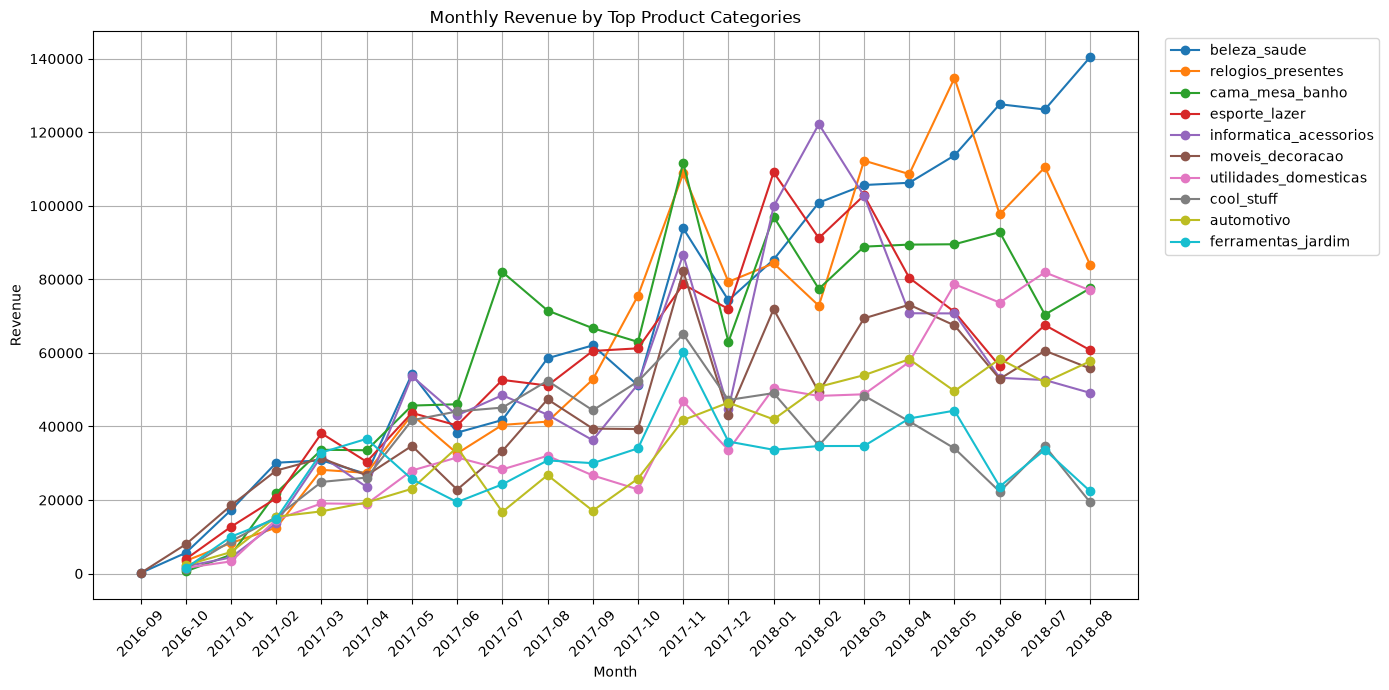

In [29]:
plt.figure(figsize=(14,7))

for category in top_categories:
    temp = top_category_monthly[
        top_category_monthly["product_category_name"] == category
    ]

    plt.plot(
        temp["order_purchase_timestamp"],
        temp["total_order_value"],
        marker="o",
        label=category
    )

plt.title("Monthly Revenue by Top Product Categories")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# EDA 4: Customer Retention & Repeat Purchase Analysis

## Business Question
Are customers making repeat purchases or purchasing only once?

## Business Importance

Acquiring new customers is expensive.

Retaining existing customers generally costs less and often leads to higher long-term profitability.

Understanding repeat purchase behavior helps the company evaluate customer loyalty and the effectiveness of its customer retention strategies.

## Analysis Performed

- Counted the number of unique orders placed by each customer.
- Classified customers into:
  - One-time Customers
  - Repeat Customers
- Calculated the distribution of customer types.
- Measured the overall repeat purchase rate.

## Key Findings

The analysis identifies whether business growth is primarily driven by:

- New customer acquisition
- Existing customer loyalty
- A combination of both

This provides insight into the overall health of the customer base.

## Business Insight

If most customers purchase only once:

- Growth is acquisition-driven.
- The business should focus on improving customer retention.
- Loyalty programs, personalized recommendations, and remarketing campaigns may increase repeat purchases.

If repeat customers represent a significant share:

- Existing retention strategies are effective.
- Customer Lifetime Value (CLV) is likely increasing.
- Marketing investment can focus on both acquisition and loyalty.

## Possible Business Recommendations

- Introduce loyalty or rewards programs.
- Send personalized product recommendations.
- Offer post-purchase discounts to encourage repeat buying.
- Develop customer segmentation strategies based on purchase frequency.
- Monitor repeat purchase rate as a core business KPI.

In [38]:
customer_orders = (
    master_df
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_orders.rename(
    columns={"order_id": "Number of Orders"},
    inplace=True
)

In [40]:
customer_orders.columns

Index(['customer_unique_id', 'Number of Orders'], dtype='str')

In [41]:
customer_orders.columns = [
    "customer_id",
    "number_of_orders",
    "customer_type"
]

ValueError: Length mismatch: Expected axis has 2 elements, new values have 3 elements

In [42]:
customer_orders.columns = [
    "customer_id",
    "number_of_orders",
    "customer_type"
]

ValueError: Length mismatch: Expected axis has 2 elements, new values have 3 elements

In [43]:
customer_orders.columns

Index(['customer_unique_id', 'Number of Orders'], dtype='str')

In [44]:
customer_orders.columns = [
    "customer_unique_id",
    "number_of_orders"
]

In [45]:
customer_orders["customer_type"] = np.where(
    customer_orders["number_of_orders"] > 1,
    "Repeat",
    "One-time"
)

In [46]:
customer_orders.head()

,customer_unique_id,number_of_orders,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time
2,0000f46a3911fa3c0805444483337064,1,One-time
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-time
4,0004aac84e0df4da2b147fca70cf8255,1,One-time


In [47]:
repeat_rate = (
    customer_orders["customer_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

repeat_rate

customer_type
One-time    96.88
Repeat       3.12
Name: proportion, dtype: float64

# 📊 EDA 5: Customer Reviews & Satisfaction Analysis

## 🎯 Business Objective

Customer satisfaction plays a critical role in customer retention, brand reputation, and long-term revenue growth. This analysis aims to understand how customers rate their shopping experience and identify patterns in review scores.

## ❓ Business Questions

- What is the overall distribution of customer review scores?
- Are customers generally satisfied with their purchases?
- Which review ratings occur most frequently?
- What business insights can be derived from customer feedback?

## 📈 Metrics Analyzed

- Review Score Distribution
- Percentage of Positive, Neutral, and Negative Reviews
- Average Customer Rating

## 💼 Business Importance

Understanding customer reviews helps businesses:

- Improve customer experience and satisfaction.
- Detect operational issues such as delayed deliveries or poor product quality.
- Build customer loyalty and increase repeat purchases.
- Prioritize improvements that have the greatest impact on customer retention.

In [49]:
[col for col in master_df.columns if "review" in col.lower()]

['review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [50]:
review_distribution = (
    master_df["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

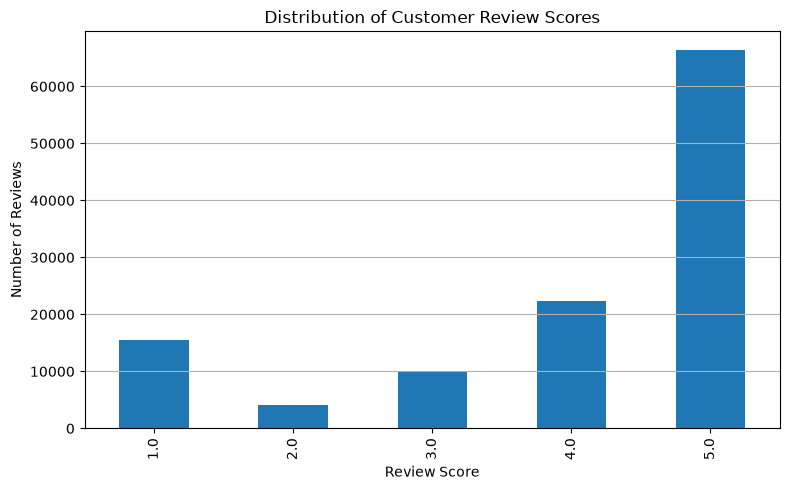

In [51]:
plt.figure(figsize=(8,5))

review_distribution.plot(
    kind="bar"
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### 💼 Business Insight

The review distribution is heavily skewed toward 5-star ratings, indicating that most customers are highly satisfied with their purchases.

However, a noticeable number of 1-star reviews still exists. These negative experiences may be linked to delayed deliveries, damaged products, incorrect orders, or poor product quality.

Improving the root causes behind low ratings could significantly increase customer retention and overall brand reputation.

## 📊 EDA 6: Relationship Between Product Price and Customer Ratings

### 🎯 Business Question
Do customers who purchase higher-priced products tend to leave better or worse review scores?

### 📌 Business Importance

Pricing directly influences customer expectations.

Customers paying premium prices often expect:
- Higher product quality
- Better packaging
- Faster delivery
- Excellent customer service

If expensive products consistently receive lower ratings, it may indicate that customer expectations are not being met.

Understanding this relationship helps businesses optimize pricing strategies while maintaining customer satisfaction.

In [53]:
[col for col in master_df.columns if "price" in col.lower()]

['price']

In [54]:
price_by_review = (
    master_df
    .groupby("review_score")["price"]
    .mean()
    .round(2)
)

price_by_review

review_score
1.0    127.87
2.0    116.82
3.0    109.15
4.0    119.03
5.0    121.30
Name: price, dtype: float64

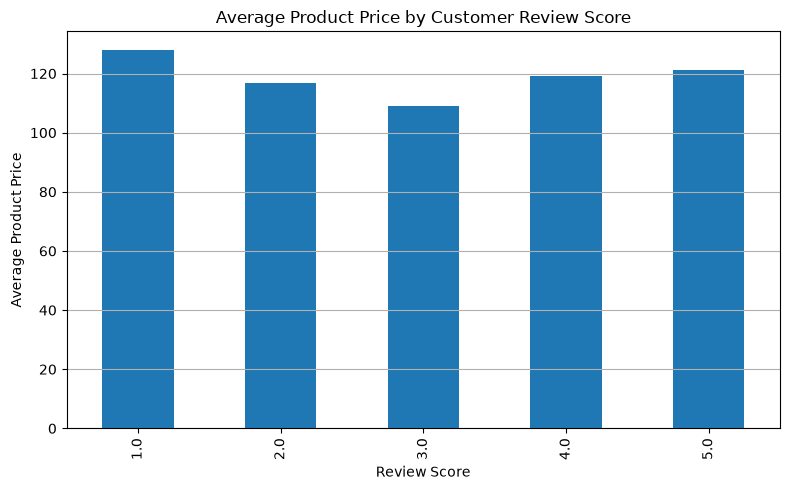

In [55]:
plt.figure(figsize=(8, 5))

price_by_review.plot(
    kind="bar"
)

plt.title("Average Product Price by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Product Price")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### 💼 Business Insight

Average product prices remain relatively consistent across all review scores, suggesting that price alone is not a strong driver of customer satisfaction.

Interestingly, the highest average price is associated with 1-star reviews, indicating that customers purchasing premium-priced products may have higher expectations. When those expectations are not met, dissatisfaction can be greater.

Overall, factors such as product quality, delivery performance, and customer experience appear to have a stronger influence on review ratings than product price itself.





## 📊 EDA 7: Delivery Performance & Customer Satisfaction

### 🎯 Business Question

Does delivery delay influence customer review ratings?

### 📌 Business Importance

Delivery performance is a key driver of customer satisfaction.

Late deliveries can negatively impact customer experience even when product quality is excellent.

By analyzing the relationship between delivery delays and review scores, businesses can identify whether improving logistics could increase customer satisfaction and reduce negative reviews.

In [56]:
[col for col in master_df.columns if "deliver" in col.lower()]

['order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'delivery_delay']

In [57]:
[col for col in master_df.columns if "estimated" in col.lower()]

['order_estimated_delivery_date']

In [58]:
[col for col in master_df.columns if "purchase" in col.lower()]

['order_purchase_timestamp', 'purchase_weekday']

In [59]:
delay_by_review = (
    master_df
    .groupby("review_score")["delivery_delay"]
    .mean()
    .round(2)
)

delay_by_review

review_score
1.0    -5.99
2.0    -9.75
3.0   -11.11
4.0   -12.47
5.0   -13.44
Name: delivery_delay, dtype: float64

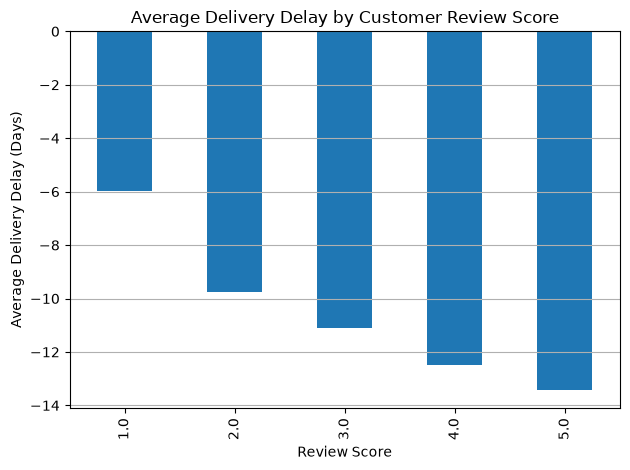

In [60]:
import matplotlib.pyplot as plt

delay_by_review.plot(
    kind="bar"
)

plt.title("Average Delivery Delay by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (Days)")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### 💼 Business Insight

Most orders were delivered before the estimated delivery date, with an average delivery occurring approximately 12 days early. Only 7,559 orders experienced delivery delays. Customers who received their orders earlier generally provided higher review scores, indicating that faster delivery positively influences customer satisfaction. While delivery is not the only factor affecting reviews, timely logistics appear to contribute significantly to a better customer experience.

In [61]:
master_df["delivery_delay"].describe()

count    115722.000000
mean        -12.048392
std          10.163801
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay, dtype: float64

In [62]:
(master_df["delivery_delay"] > 0).sum()

np.int64(7559)

# 📊 EDA 8: Seller Performance Analysis

## 🎯 Business Question

Which sellers generate the highest revenue, receive the best customer ratings, and contribute the most to the marketplace's overall success?

---

## 📌 Business Importance

Sellers are the backbone of an e-commerce marketplace. Understanding seller performance enables the business to identify top-performing partners, improve customer satisfaction, and optimize marketplace growth.

Analyzing seller performance helps the business:

- Identify high-revenue sellers.
- Recognize sellers with consistently positive customer reviews.
- Detect underperforming sellers who may require operational support.
- Develop incentive programs for top-performing sellers.
- Improve marketplace quality by encouraging better seller performance.

Ultimately, this analysis supports strategic decision-making by highlighting which sellers create the greatest business value and customer satisfaction.

In [64]:
[col for col in master_df.columns if "seller" in col.lower()]

['seller_id']

In [65]:
seller_revenue = (
    master_df
    .groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

seller_revenue

seller_id
7c67e1448b00f6e969d365cea6b010ab    512645.19
1025f0e2d44d7041d6cf58b6550e0bfa    312456.49
4a3ca9315b744ce9f8e9374361493884    306138.80
1f50f920176fa81dab994f9023523100    291918.98
53243585a1d6dc2643021fd1853d8905    284903.08
da8622b14eb17ae2831f4ac5b9dab84a    276578.63
4869f7a5dfa277a7dca6462dcf3b52b2    264166.12
955fee9216a65b617aa5c0531780ce60    236414.48
fa1c13f2614d7b5c4749cbc52fecda94    206513.23
7e93a43ef30c4f03f38b393420bc753a    185134.21
Name: payment_value, dtype: float64

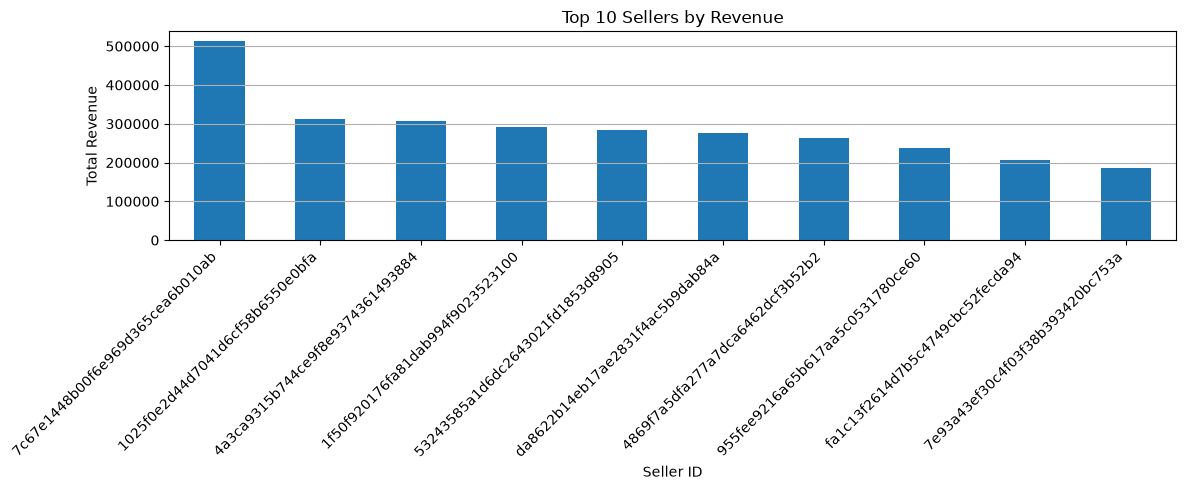

In [66]:

seller_revenue.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [68]:
seller_orders = (
    master_df
    .groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

seller_orders

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64

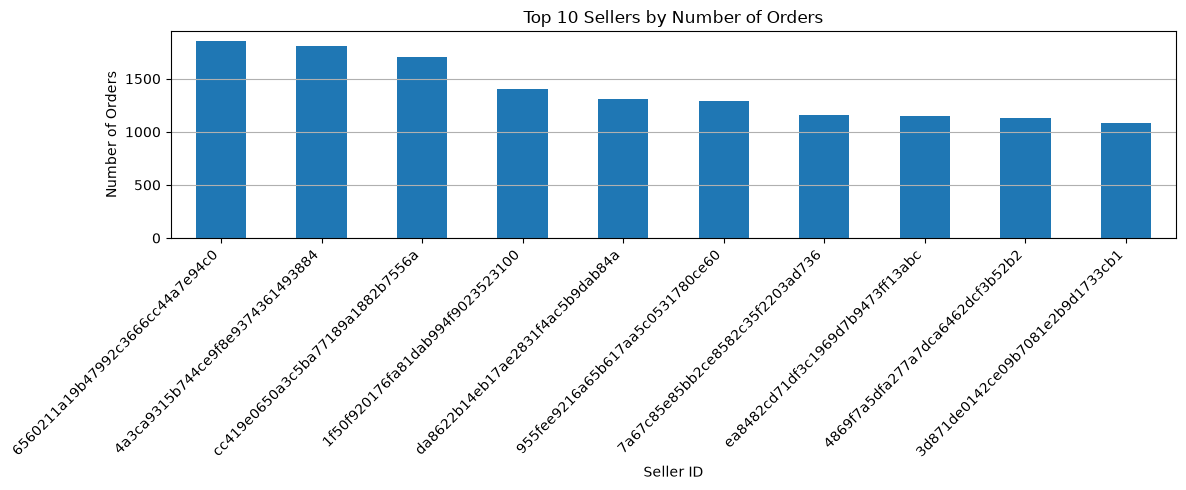

In [70]:
seller_orders.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Sellers by Number of Orders")
plt.xlabel("Seller ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [71]:
seller_reviews = (
    master_df
    .groupby("seller_id")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

seller_reviews

seller_id
c3251e13f1bbda6c74e37c160f991e19    5.0
3986c0b54f6b748b75e7bd4e092aa3e5    5.0
39a5005f2605cbdb4f9ac14485cabfd1    5.0
95cca791657aabeff15a07eb152d7841    5.0
d149de2f383552baea37a7198c2296ce    5.0
94d76e96eedd976258cd3278ce56d5f2    5.0
94ca168e8bcb407ab85c5da308863027    5.0
3ac588cd562971392504a9e17130c40b    5.0
93bef6edaa84956e8e575016449b6351    5.0
3b18f9856c6eb2413eafedb58e9eecd9    5.0
Name: review_score, dtype: float64

In [72]:
seller_stats = (
    master_df
    .groupby("seller_id")
    .agg(
        avg_review=("review_score", "mean"),
        total_orders=("order_id", "nunique")
    )
)

seller_stats = seller_stats[
    seller_stats["total_orders"] >= 20
]

top_rated_sellers = (
    seller_stats
    .sort_values("avg_review", ascending=False)
    .head(10)
)

top_rated_sellers

,avg_review,total_orders
seller_id,,
48efc9d94a9834137efd9ea76b065a38,5.000000,33
41c2bad7229b0c25e6becf179ebf63ff,4.956522,20
02f5837340d7eb4f653d676c7256523a,4.833333,30
d9bd94811c3338dceb4181f3dbc0c73e,4.822581,54
d13e50eaa47b4cbe9eb81465865d8cfc,4.816901,67
42fa4ee7240e9b8eb4576358ec142ba7,4.809524,22
7ade73f1b9b4e965f9009a4c3a7e2c15,4.800000,27
3785b653b1b82de85ab47dd139938091,4.750000,21
013900e863eace745d3ec7614cab5b1a,4.740741,23


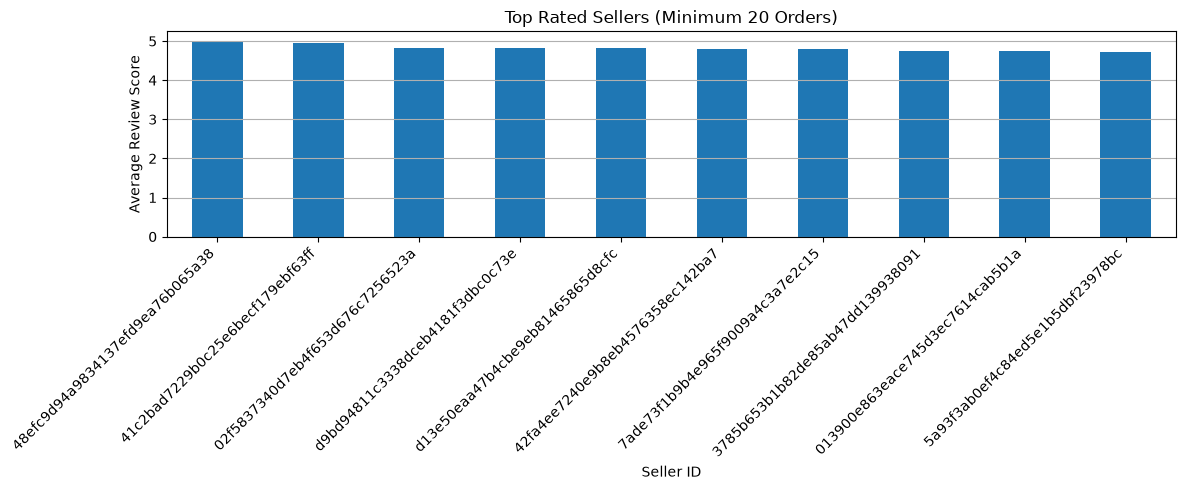

In [73]:
top_rated_sellers["avg_review"].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Rated Sellers (Minimum 20 Orders)")
plt.xlabel("Seller ID")
plt.ylabel("Average Review Score")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

📦 Business Insight

The highest-rated sellers consistently maintain excellent customer satisfaction even after handling a significant number of orders.

Applying a minimum order threshold removes unreliable results from sellers with only a few transactions, making the analysis more representative of true seller performance.

These sellers can be studied as benchmarks for operational excellence, customer service, and fulfillment practices that could be replicated across the marketplace.

# 💳 EDA 9: Payment Behavior Analysis

## 🎯 Business Question

How do customer payment methods influence purchasing behavior, order value, and overall revenue?

---

## 📌 Business Importance

Payment behavior is a key aspect of customer purchasing decisions and directly impacts business revenue.

By analyzing payment methods, installment usage, and transaction values, businesses can:

- Understand customers' preferred payment options.
- Identify which payment methods generate the highest revenue.
- Analyze whether installment payments encourage larger purchases.
- Optimize checkout strategies to improve conversion rates.
- Support negotiations with payment service providers and reduce transaction costs.

These insights help improve customer experience while maximizing revenue and operational efficiency.

In [74]:
[col for col in master_df.columns if "payment" in col.lower()]

['payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

In [75]:
master_df["payment_type"].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

In [78]:
payment_revenue = (
    master_df
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)
payment_revenue

payment_type
credit_card    15775450.54
boleto          4110920.74
voucher          435917.84
debit_card       257374.89
not_defined           0.00
Name: payment_value, dtype: float64

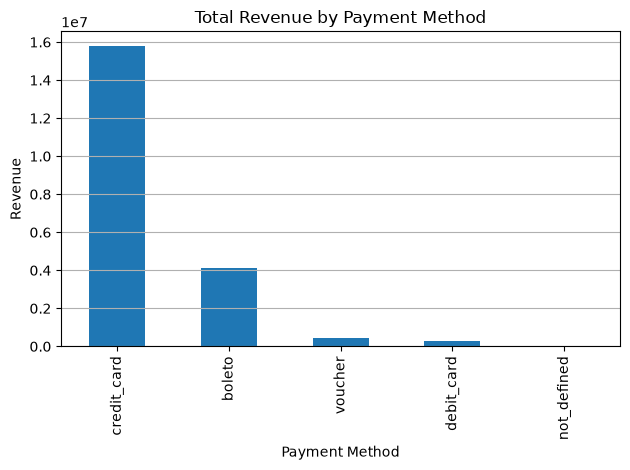

In [79]:
import matplotlib.pyplot as plt

payment_revenue.plot(
    kind="bar"
)

plt.title("Total Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 💼 Business Insight

Credit cards are the dominant payment method, accounting for the majority of transactions and generating the highest revenue by a substantial margin.

Boleto remains an important secondary payment option, while voucher and debit card transactions contribute only a small portion of overall revenue.

These findings suggest that optimizing the credit card checkout experience should remain a business priority, while promotional campaigns can encourage customers using alternative payment methods to increase conversion rates.

# 👥 EDA 10: Customer Lifetime Value & Repeat Purchase Analysis

## 🎯 Business Question

Which customers contribute the most revenue, and how much of the business depends on repeat purchases?

## 📌 Business Importance

Customer retention is often more profitable than acquiring new customers.

By identifying repeat buyers and high-value customers, businesses can:

- Improve customer retention strategies.
- Design personalized loyalty programs.
- Identify VIP customers for exclusive promotions.
- Increase Customer Lifetime Value (CLV).
- Reduce customer acquisition costs by encouraging repeat purchases.

Understanding customer purchasing behavior enables businesses to maximize long-term profitability rather than focusing only on one-time sales.

In [80]:
[col for col in master_df.columns if "customer" in col.lower()]

['customer_id',
 'order_delivered_customer_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [81]:
customer_summary = (
    master_df.groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_value", "sum"),
        average_order_value=("payment_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

customer_summary.head(10)

,total_orders,total_revenue,average_order_value
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,1,109312.64,13664.0800
698e1cf81d01a3d389d96145f7fa6df8,1,45256.00,2262.8000
c402f431464c72e27330a67f7b94d4fb,1,44048.00,2202.4000
4007669dec559734d6f53e029e360987,1,36489.24,6081.5400
ef8d54b3797ea4db1d63f0ced6a906e9,1,30186.00,3018.6000
763c8b1c9c68a0229c42c9fc6f662b93,1,29099.52,7274.8800
c8460e4251689ba205045f3ea17884a1,4,27935.46,1163.9775
eae0a83d752b1dd32697e0e7b4221656,2,25051.89,1670.1260
3d47f4368ccc8e1bb4c4a12dbda7111b,1,22346.60,2234.6600


In [82]:
repeat_customers = (
    customer_summary["total_orders"] > 1
).sum()

one_time_customers = (
    customer_summary["total_orders"] == 1
).sum()

print(f"Repeat Customers: {repeat_customers:,}")
print(f"One-Time Customers: {one_time_customers:,}")
print(f"Repeat Customer Rate: {repeat_customers / len(customer_summary):.2%}")

Repeat Customers: 2,997
One-Time Customers: 93,099
Repeat Customer Rate: 3.12%


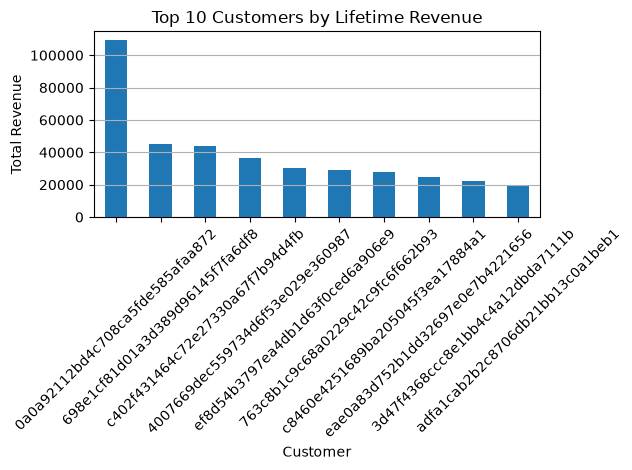

In [83]:
import matplotlib.pyplot as plt

top_customers = customer_summary.head(10)

top_customers["total_revenue"].plot(
    kind="bar"
)

plt.title("Top 10 Customers by Lifetime Revenue")
plt.xlabel("Customer")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 💼 Business Insight

The marketplace has a relatively low repeat customer rate of **3.12%**, indicating that most purchases come from one-time buyers.

Despite this, a small group of repeat customers contributes significant lifetime value, highlighting the importance of customer retention strategies.

Investing in loyalty programs, personalized marketing, and post-purchase engagement could increase repeat purchases, improve customer lifetime value, and drive sustainable long-term revenue growth.